# Practica Prueba técnica Globant

## Sección 3
### Prophet | ARIMA | SARIMA | XGBoost Forecasting

ARIMA - AutoRegressive Integrated Moving Average  
Predicción de información futura basado en información pasada, especialmente cosas que cambian con el tiempo como ventas  
AR: Relacionamiento lineal entre valor actual de la serie y su valor anterior - PATRONES  
I: Diferenciamiento de informacion para hacerla estacionaria, haciendo que sus propiedades estadistica, como media y varianza, no cambien con el tiempo - TENDENCIAS   
MA: Modelos de relación entre el valor actual y errores de estimación anteriores -  CORRECCIÓN 

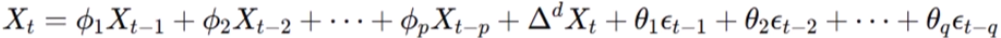

p, d & q: hiperparametro para el modelo arima  
  
p: Orden del proceso autoregresivo - Cuanta información del pasado usaremos
d: numero de steps de diferenciamiento a incluir en el algoritmo - Cuantas veces ajustar la información para eliminar tendencias de largo plazo  
q: Orden del proceso de MA - Cuanto error del pasado considerar  

SARIMA - Seasonal Autoregressive Integrated Moving Average

Funciona como ARIMA pero considerando tendencias.

PROPHET  
Es un procedimiento de estimacion de información de series de tiempo basado en un modelo aditivo donde los efectos de tendencias no lineares son tomados en cuenta (anual, semanal, diario).  
Prophet funciona correctamente con series de tiempo que tienen un fuerte efecto de estacionalidad y muchas estaciones de informacion pasada.  
Utiliza un modelo de regresion aditiva con 4 elementos. 
- Elemento linear. Automaticamente prophet toma puntos que cambian en la información e identifica las tendencias  
- Un componente anual modelado utilizando las series de fourier  
- Un componente semanal  
- Un componente de festividades puede ser ingreasado manualmente  


XGBoost  
Combina  Gradient boosting  que es: Algoritmo de aprendizaje supervisado, que intenta hacer la predicción mediante la combinación de estimados de un set de estimadores mas simples. Y arboles de decisiones

Prophet está diseñado para series temporales de "estilo de negocios", las cuales suelen tener componentes estacionales fuertes y múltiples, así como brechas en los datos.  
Fortalezas clave: Maneja muy bien los datos faltantes, los valores atípicos y los cambios abruptos de tendencia.  
Casos de uso:  
- Pronósticos con estacionalidades complejas y múltiples (por ejemplo, diaria + semanal + anual).  
- Campañas de marketing donde los días festivos o eventos específicos alteran las tendencias.  
- Cuando necesitas un modelo rápido y confiable con un ajuste mínimo.
  
ARIMA es un modelo estadístico tradicional que se basa en valores pasados (autorregresión) y errores pasados (media móvil).  
Fortalezas clave: Muy preciso para conjuntos de datos estacionarios, estables y a corto plazo.  
Casos de uso:  
- Pronósticos a corto plazo (por ejemplo, las próximas horas o días).  
- Datos con una autocorrelación lineal clara (los valores pasados influyen fuertemente en los futuros).  
- Cuando tienes datos limitados y no puedes usar modelos complejos de aprendizaje automático (ML).  
  
XGBoost es un enfoque de aprendizaje automático que sobresale en la captura de relaciones no lineales al tratar las series temporales como un problema de regresión supervisada.  
Fortalezas clave: Extremadamente preciso, maneja una alta dimensionalidad y captura interacciones complejas entre características.  
Casos de uso:  
- Grandes conjuntos de datos donde existen patrones complejos y no lineales.  
- Cuando tienes muchas características externas y no relacionadas (regresores) que afectan al objetivo.  
- Cuando los datos no son estacionarios y tienen patrones irregulares.  



In [1]:
%pip uninstall prophet -y

Found existing installation: prophet 1.3.0
Uninstalling prophet-1.3.0:
  Successfully uninstalled prophet-1.3.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install prophet pmdarima statsmodels xgboost scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from pmdarima import auto_arima
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error


Importing plotly failed. Interactive plots will not work.


In [4]:
df = pd.read_csv('train.csv', parse_dates=['Date'])
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
store_1 = df[df['Store'] == 1].sort_values('Date').copy()
store_1.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1016095,1,2,2013-01-01,0,0,0,0,a,1
1014980,1,3,2013-01-02,5530,668,1,0,0,1
1013865,1,4,2013-01-03,4327,578,1,0,0,1
1012750,1,5,2013-01-04,4486,619,1,0,0,1
1011635,1,6,2013-01-05,4997,635,1,0,0,1


<Axes: xlabel='Date'>

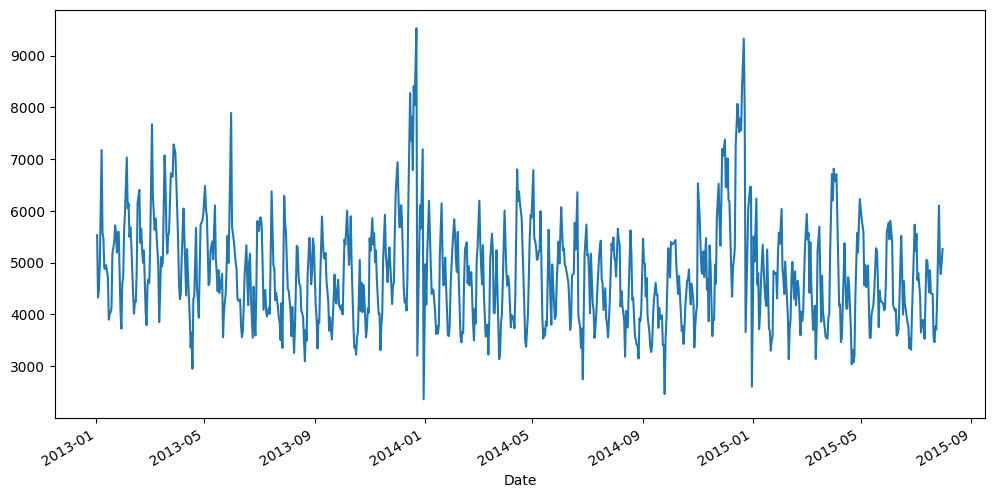

In [6]:
store_1 = store_1[store_1['Sales'] > 0]
store_1.set_index('Date', inplace=True)
store_1['Sales'].plot(figsize=(12, 6))

Text(0.5, 1.0, 'Ventas del último año para la tienda 1')

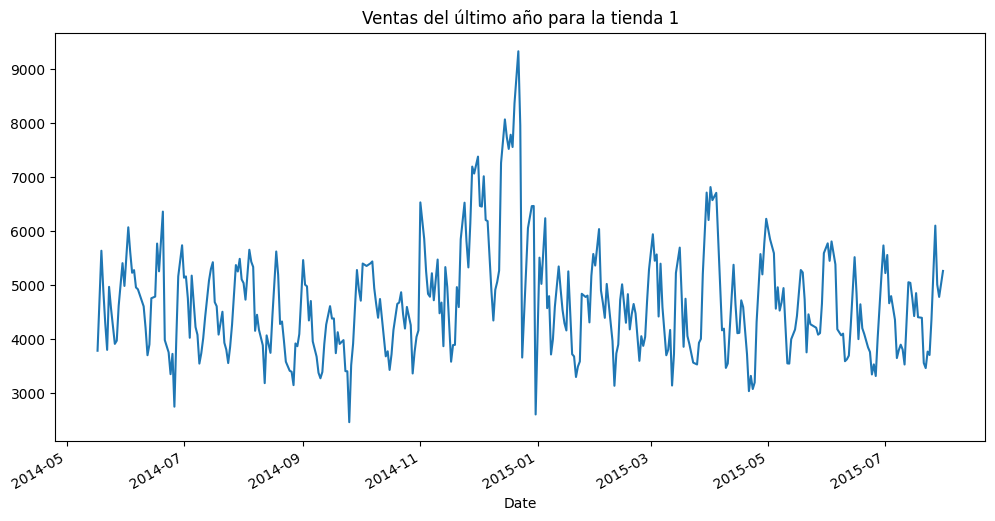

In [7]:
store_1['Sales'][-365:].plot(figsize=(12, 6))
plt.title('Ventas del último año para la tienda 1')

In [8]:
dias_a_predecir = 90
train = store_1['Sales'].iloc[:-dias_a_predecir]
test = store_1['Sales'].iloc[-dias_a_predecir:]
print(f'Tamaño del set de entrenamiento: {len(train)} | {train.index.min().date()} a {train.index.max().date()}')
print(f'Tamaño del set de prueba: {len(test)} | {test.index.min().date()} a {test.index.max().date()}')

Tamaño del set de entrenamiento: 691 | 2013-01-02 a 2015-04-13
Tamaño del set de prueba: 90 | 2015-04-14 a 2015-07-31


In [9]:
arima = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True, error_action='ignore')

predicciones_arima = arima.predict(n_periods=dias_a_predecir)

rmse_arima = np.sqrt(mean_squared_error(test.values, predicciones_arima.values))
print(f'RMSE ARIMA: {rmse_arima:.2f}')

pred_arima = pd.Series(predicciones_arima.values, index=test.index)

RMSE ARIMA: 713.18


c:\Users\nacos\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [33]:
sarima = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True, error_action='ignore', m=7, max_p=4, max_q=4, max_P=2, max_Q=1)

predicciones_sarima = sarima.predict(n_periods=dias_a_predecir)

rmse_sarima = np.sqrt(mean_squared_error(test.values, predicciones_sarima.values))
print(f'RMSE SARIMA: {rmse_sarima:.2f}')

pred_sarima = pd.Series(predicciones_sarima.values, index=test.index)

print(sarima.seasonal_order)

RMSE SARIMA: 732.87
(0, 0, 0, 0)


c:\Users\nacos\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


09:28:55 - cmdstanpy - INFO - Chain [1] start processing
09:28:55 - cmdstanpy - INFO - Chain [1] done processing


RMSE Prophet: 759.34


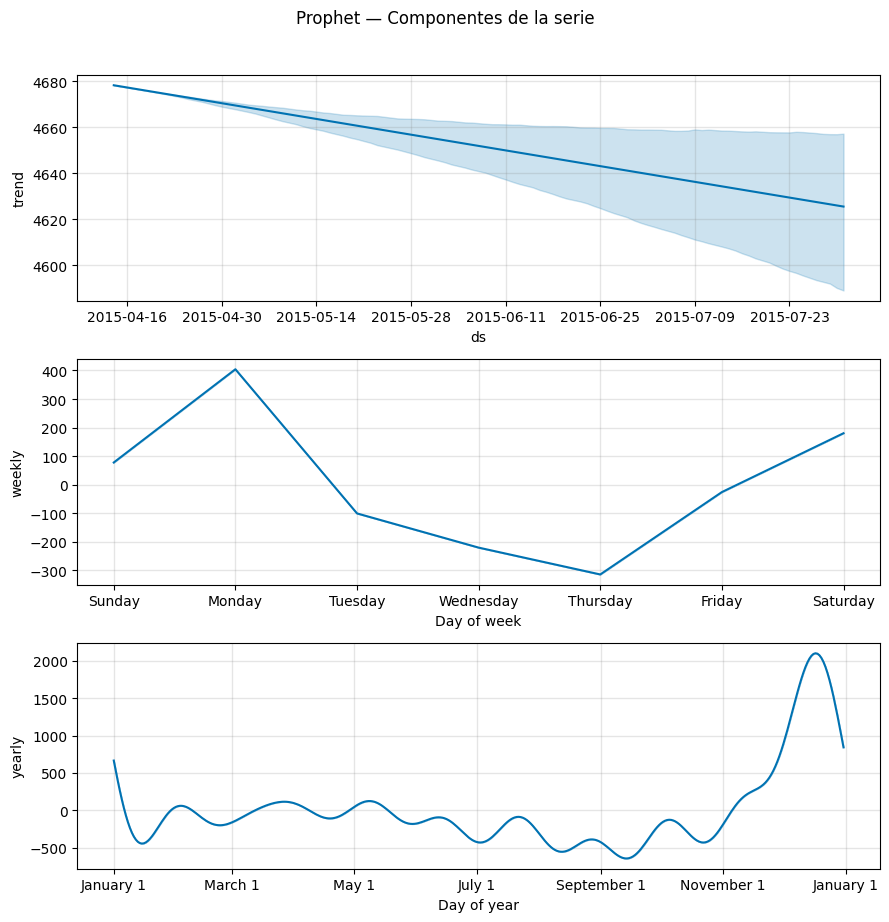

In [42]:
df_prophet = train.reset_index().rename(columns={'Date': 'ds', 'Sales': 'y'})
model_prophet = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=True, changepoint_prior_scale=0.3)
model_prophet.fit(df_prophet)

future = pd.DataFrame({'ds':test.index})
forecast = model_prophet.predict(future)
pred_prophet = pd.Series(forecast['yhat'].values, index=test.index)
pred_prophet = pred_prophet.clip(lower=0, upper=None)

rmse_prophet = np.sqrt(mean_squared_error(test, pred_prophet))
print(f'RMSE Prophet: {rmse_prophet:.2f}')

fig = model_prophet.plot_components(forecast)
plt.suptitle('Prophet — Componentes de la serie', y=1.02)
plt.tight_layout()
plt.show()

In [35]:
def crear_features(serie):
    df_feat = pd.DataFrame({'y': serie})
    df_feat['dayofweek'] = serie.index.dayofweek
    df_feat['month'] = serie.index.month
    df_feat['dayofmonth'] = serie.index.day
    df_feat['weekofyear'] = serie.index.isocalendar().week.astype(int)
    df_feat['lag_7'] = serie.shift(7)
    df_feat['lag_14'] = serie.shift(14)
    df_feat['lag_21'] = serie.shift(21)
    df_feat['lag_28'] = serie.shift(28)
    df_feat['rolling_mean_7'] = serie.shift(1).rolling(window=7).mean()
    df_feat['rolling_mean_28'] = serie.shift(1).rolling(window=28).mean()
    return df_feat.dropna()

serie_completa = store_1['Sales']
df_features = crear_features(serie_completa)
features = ['dayofweek', 'month', 'dayofmonth', 'weekofyear', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'rolling_mean_7', 'rolling_mean_28']
X_train = df_features.loc[train.index.intersection(df_features.index)][features]
y_train = df_features.loc[train.index.intersection(df_features.index)]['y']
X_test = df_features.loc[test.index.intersection(df_features.index)][features]
y_test = df_features.loc[test.index.intersection(df_features.index)]['y']

model_xgb = XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.1, random_state=42)

model_xgb.fit(X_train, y_train)
pred_xgb = pd.Series(model_xgb.predict(X_test), index=y_test.index)
pred_xgb = pred_xgb.clip(lower=0, upper=None)

rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
print(f'RMSE XGBoost: {rmse_xgb:.2f}')

RMSE XGBoost: 578.65


In [36]:
resultados = {}
resultados['ARIMA'] = rmse_arima
resultados['SARIMA'] = rmse_sarima
resultados['Prophet'] = rmse_prophet
resultados['XGBoost'] = rmse_xgb


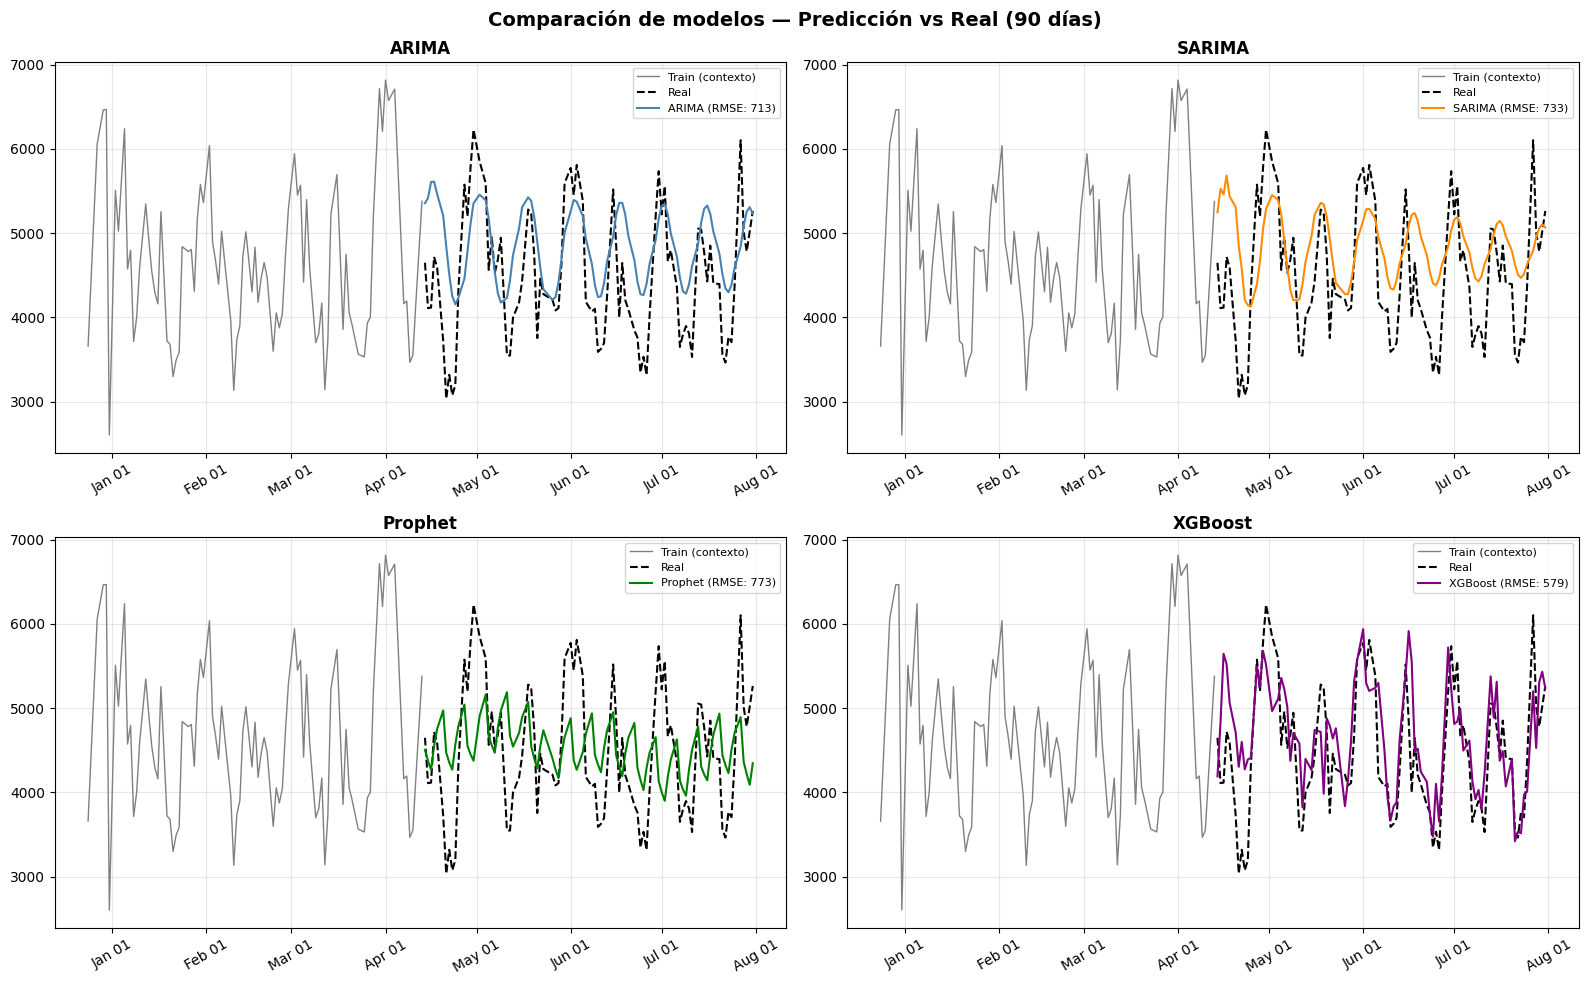

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

modelos = {
    'ARIMA':   pred_arima,
    'SARIMA':  pred_sarima,
    'Prophet': pred_prophet,
    'XGBoost': pred_xgb,
}
colores = ['steelblue', 'darkorange', 'green', 'purple']

for ax, (nombre, pred), color in zip(axes, modelos.items(), colores):
    contexto = train.iloc[-90:]
    ax.plot(contexto.index, contexto.values, color='gray', linewidth=1, label='Train (contexto)')
    ax.plot(test.index, test.values, color='black', linewidth=1.5, label='Real', linestyle='--')
    ax.plot(pred.index, pred.values, color=color, linewidth=1.5, label=f'{nombre} (RMSE: {resultados[nombre]:,.0f})')
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Comparación de modelos — Predicción vs Real (90 días)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusion

Los resultados del ejercicio muestran a XGBoost como el modelo con mejor desempeño con un RMSE de 579, comparado con ARIMA (713), SARIMA (733) y Prophet (759). Esto se debe a que el uso de lags de 7, 14, 21 y 28 días le permite al modelo encontrar patrones y correlaciones de manera flexible, capturando el ciclo semanal del retail directamente como features sin imponer una estructura matemática predefinida.
Prophet, aunque consistente, fue el modelo con peor desempeño en este dataset. Su naturaleza conservadora lo lleva a suavizar los picos de ventas — modela tendencias globales pero no captura bien la variabilidad local reciente que los lags de XGBoost sí capturan.
SARIMA y ARIMA convergieron a resultados similares porque el algoritmo detectó, a través de la penalización AIC, que la estacionalidad semanal en este dataset no era suficientemente estable para justificar el componente estacional — SARIMA terminó con parámetros (0,0,0,0) convirtiéndose esencialmente en ARIMA.
Esto define criterios claros de uso: ARIMA y SARIMA son preferibles cuando los datos tienen estructura lineal clara o cuando el historial es limitado. Prophet cuando existen eventos y festivos conocidos que afectan la serie. XGBoost cuando hay gran cantidad de datos, patrones complejos, y variables externas como presupuesto de pauta, canal o tipo de campaña que pueden incorporarse como features adicionales — siendo el modelo más adecuado para calcular ROI y predecir conversiones en un contexto de Data, Analytics y Martech.